# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  state_neuron = []  # Initialize output list

  for i in range(len(X1)):
        s = X1[i] + X2[i]   # element-wise addition

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

  return state_neuron


  # Perform an element wise addition of two input arrays stored in a new array(list):
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.



In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []  # Initialize output list

    for i in range(len(X1)):
        s = X1[i] + X2[i]  # element-wise addition

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons.

Ans:- Limitations of McCulloch-Pitts (MCP) neuron are :
1. No Learning Capability.
2. Fixed Weights and Threshold.
3. Only Binary Inputs and Outputs.
4. Limited to Linearly Separable Problems.
5. Oversimplified Model.
6. No Gradient-Based Optimization.

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron. {Can you devise a if else rules.}

Ans:-

def MCP_XOR_logic(x1, x2):
    
    OR = 1 if (x1 + x2) >= 1 else 0
    
    AND = 1 if (x1 + x2) >= 2 else 0
    
    if OR == 1 and AND == 0:
        return 1
    else:
        return 0

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

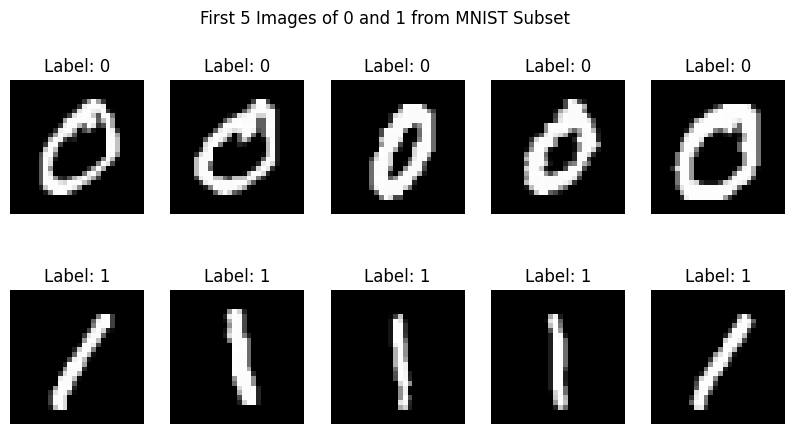

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias

    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    for epoch in range(epochs):
        for i in range(len(X)):
            # Linear combination
            Z = np.dot(X[i], weights) + bias

            # Step activation function
            y_pred = 1 if Z >= 0 else -1

            # Update rule (only if misclassified)
            if y[i] != y_pred:
                weights = weights + learning_rate * y[i] * X[i]
                bias = bias + learning_rate * y[i]

    # Final predictions for accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.sum(y_pred_all == y)
    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  6742


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.5323


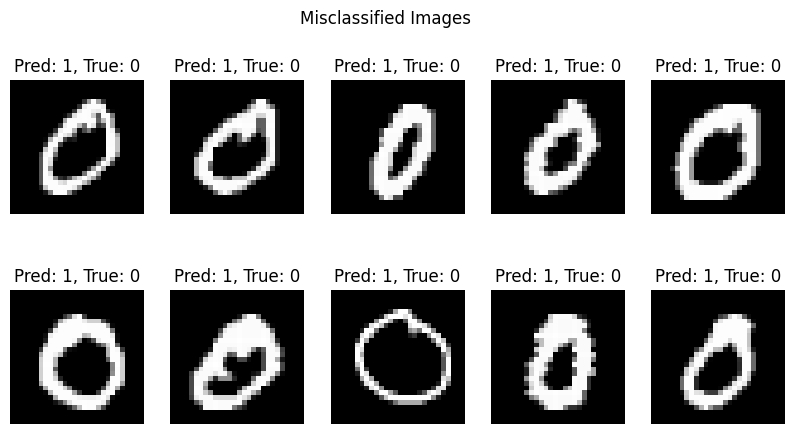

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Question - 1: What does the shape of X represent?

Ans:- The shape of X represents the number of samples (rows) and number of features (columns) in the dataset.

Question - 2: What does the shape of Y represent?

Ans:- The shape of y represents the number of labels (target outputs) in the dataset one label for each input sample (image).

Question - 3: What does the weights array represent in this context?

Ans:- The weights array represents the importance (or contribution) of each input feature (pixel) in making the prediction.

Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

Ans:- We initialize the weights to zero as a simple starting point before training begins.

Effect on training:

1. The perceptron will update the weights during learning, so starting from zero is fine.

2. However, it may make the learning process slower at the beginning, since allfeatures start with equal importance.

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Ans:- The line computes the weighted sum of inputs plus bias, which is used to make a prediction. It calculates how strongly the input features influence the output before applying the activation function.

Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?

Ans:- When the prediction is wrong, the model updates the weights and bias to reduce the error.

weights = weights + learning_rate × (y − ŷ) × X[i]

bias = bias + learning_rate × (y − ŷ)

Question - 7:Why is the final accuracy important, and what do you expect it to be?

Ans:- The final accuracy is important because it shows how well the model is correctly classifying the data. Expect it to be very high (close to 1 or 100%), since digits like 0 and 1 are usually linearly separable, making them easy for a perceptron to learn.

Question - 8:What does misclassified idx store, and how is it used in this code?

Ans:- misclassified_idx stores the indices (positions) of the samples where the model predicted incorrectly.

It is used to select and display those misclassified images so we can visually analyze the model's mistakes.

Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

Ans:- It means:- The model achieved 100% accuracy on the dataset. There are no misclassified samples, so the perceptron has learned the data perfectly.

4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv")

In [ ]:
y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values


In [ ]:
X = X / 255.0
y = np.where(y == 3, -1, 1)
print("Dataset loaded:", X.shape)

Dataset loaded: (2741, 784)


In [ ]:
def predict(X, weights, bias):
    linear_output = np.dot(X, weights) + bias
    return np.where(linear_output >= 0, 1, -1)

In [ ]:
def train_perceptron(X, y, lr=0.01, epochs=10):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            y_pred = predict(X[i], weights, bias)

            if y[i] != y_pred:
                weights += lr * y[i] * X[i]
                bias += lr * y[i]
                errors += 1

        print(f"Epoch {epoch+1}/{epochs}, Errors: {errors}")

    return weights, bias


In [ ]:
weights, bias = train_perceptron(X, y, lr=0.01, epochs=10)

Epoch 1/10, Errors: 251
Epoch 2/10, Errors: 154
Epoch 3/10, Errors: 154
Epoch 4/10, Errors: 155
Epoch 5/10, Errors: 132
Epoch 6/10, Errors: 128
Epoch 7/10, Errors: 121
Epoch 8/10, Errors: 112
Epoch 9/10, Errors: 117
Epoch 10/10, Errors: 113


In [ ]:
y_pred = predict(X, weights, bias)

accuracy = np.mean(y_pred == y)
print(f"\nAccuracy: {accuracy * 100:.2f}%")


Accuracy: 96.32%


In [ ]:
misclassified_indices = np.where(y_pred != y)[0]

print("Total Misclassified:", len(misclassified_indices))

Total Misclassified: 101


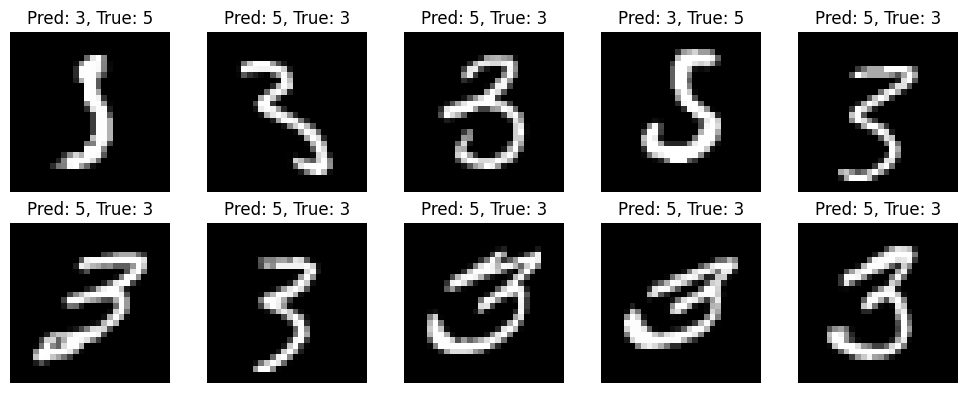

In [ ]:
def plot_misclassified(X, y_true, y_pred, indices, max_images=10):
    plt.figure(figsize=(10, 4))

    for i, idx in enumerate(indices[:max_images]):
        plt.subplot(2, 5, i + 1)

        image = X[idx].reshape(28, 28)

        plt.imshow(image, cmap='gray')
        plt.title(f"Pred: {5 if y_pred[idx]==1 else 3}, True: {5 if y_true[idx]==1 else 3}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_misclassified(X, y, y_pred, misclassified_indices)